# 2(b) Evaluate the untrained Qwen2.5-Instruct model

In [33]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

import sys
sys.path.append("../src")

from preprocessor import (
    load_and_preprocess,
    decode_prediction_to_array,
    rescale
)
from qwen import load_qwen
from lora_implemented import generate_predictions


# ====== Load Model & Tokenizer ======
model, tokenizer = load_qwen()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ====== Load Data ======
with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    trajectories = f["trajectories"][:]
    time_points = f["time"][:]

(train_set, train_idx), (val_set, val_idx) = load_and_preprocess(
         "../data/lotka_volterra_data.h5", alpha=0.36, precision=3)
val_prompt = val_set[1]

In [2]:
len(val_set[2])

200

In [34]:
# ====== Predict on entire validation set ======

all_predictions_2b = []  # list of np.ndarray, each of shape (≤30, 2)
all_gt_2b = []           # list of np.ndarray, each of shape (100, 2)

for i, system_id in enumerate(val_idx):
    prompt_string = val_set[1][i]  # 70-point LLMTIME string
    traj_gt = trajectories[system_id]

    try:
        # Predict
        pred_tokens = generate_predictions(
            prompt_string,
            tokenizer=tokenizer,
            model=model,
            device=device,
            max_new_tokens=420,
            num_samples=1,
            do_sample=False
        )[0]

        # Decode and rescale
        decoded_pred = decode_prediction_to_array(pred_tokens)
        rescaled_pred = rescale(decoded_pred, alpha=0.36)

        all_predictions_2b.append(rescaled_pred)
        all_gt_2b.append(traj_gt)

    except Exception as e:
        print(f"[{i}] System {system_id} failed: {e}")
        all_predictions.append(None)
        all_gt.append(traj_gt)


In [4]:
len(all_predictions_2b)  # 200

200

In [36]:
import torch.nn.functional as F
import math

mae_list_2b = []
system_ids_2b = []
squared_error_list_2b = []

for i, (pred, gt) in enumerate(zip(all_predictions_2b, all_gt_2b)):
    if pred is None:
        continue

    gt_shifted = gt[70:]
    pred_tensor = torch.tensor(pred)

    n = min(30, pred_tensor.shape[0], gt_shifted.shape[0])
    pred_tensor = pred_tensor[:n]
    gt_tensor = torch.tensor(gt_shifted[:n])

    # MAE
    mae = F.l1_loss(pred_tensor, gt_tensor)
    mae_list_2b.append(mae.item())
    system_ids_2b.append(i)
    
    # Squared Error (for RMSE)
    mse = F.mse_loss(pred_tensor, gt_tensor)
    squared_error_list_2b.append(mse.item())

mean_mae = sum(mae_list_2b) / len(mae_list_2b)
rmse = math.sqrt(sum(squared_error_list_2b) / len(squared_error_list_2b))

# Standard Deviation
std_mae = np.std(mae_list_2b)
std_rmse = np.std(np.sqrt(np.array(squared_error_list_2b)))

print(f"Mean Absolute Error (MAE for untrained Qwen2.5-Instruct model): {mean_mae:.4f} ± {std_mae:.4f}")
print(f"Root Mean Squared Error (RMSE for untrained Qwen2.5-Instruct model): {rmse:.4f} ± {std_rmse:.4f}")

Mean Absolute Error (MAE for untrained Qwen2.5-Instruct model): 0.8617 ± 1.6200
Root Mean Squared Error (RMSE for untrained Qwen2.5-Instruct model): 2.9489 ± 2.6754


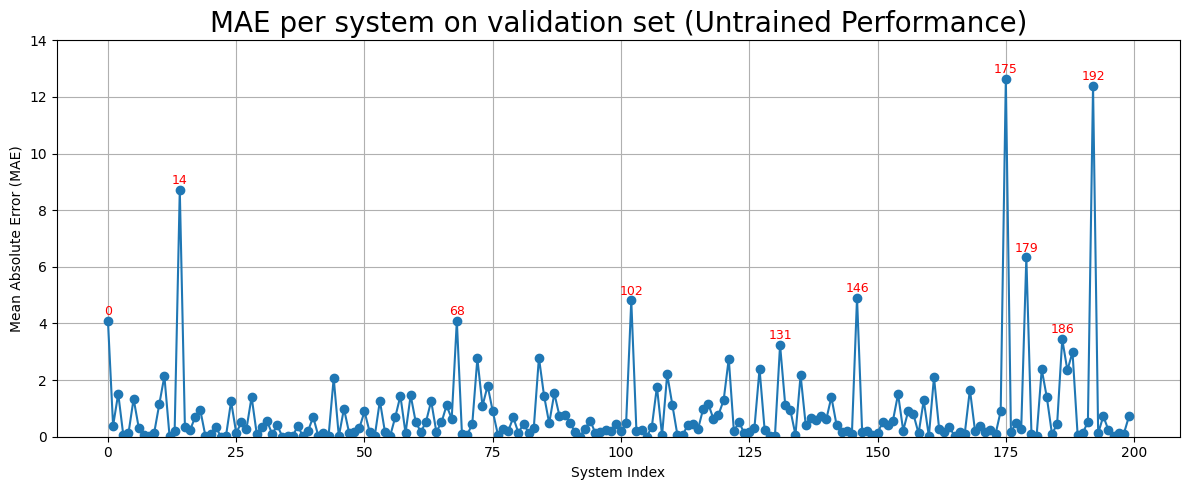

In [6]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# MAE Plot for Untrained prediction

plt.figure(figsize=(12, 5))
plt.plot(system_ids_2b, mae_list_2b, marker='o')
plt.title("MAE per system on validation set (Untrained Performance)", fontsize=20)
plt.xlabel("System Index")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(True)
plt.ylim(0,14)

# High MAE Marker
for sid, mae in zip(system_ids_2b, mae_list_2b):
    if mae > 3:
        plt.text(sid, mae + 0.1, f"{sid}", ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

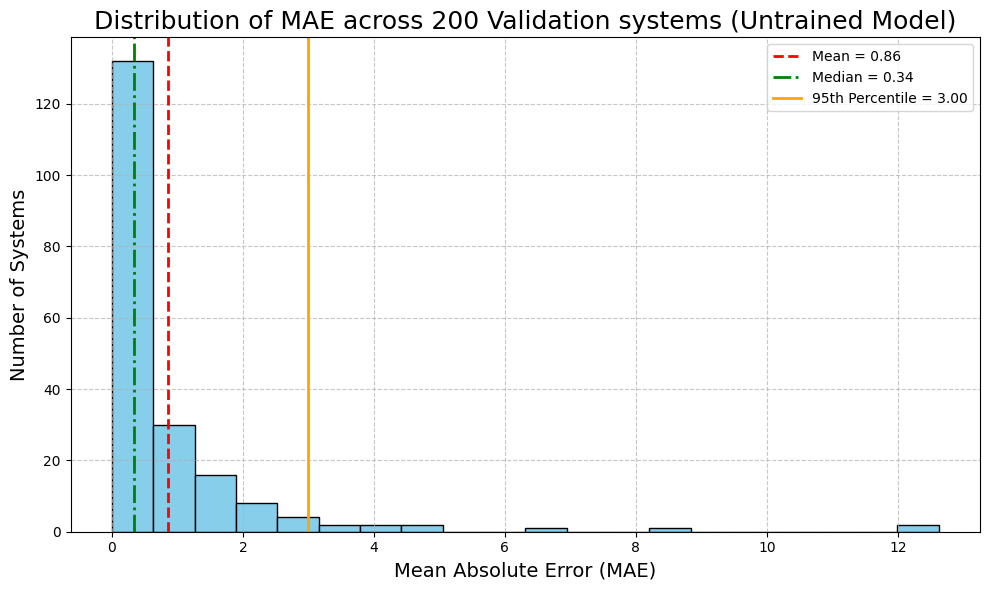

In [7]:
# Histogram of MAE values
import numpy as np
import matplotlib.pyplot as plt


mean_mae = np.mean(mae_list_2b)
median_mae = np.median(mae_list_2b)
percentile_95 = np.percentile(mae_list_2b, 95)

plt.figure(figsize=(10, 6))
plt.hist(mae_list_2b, bins=20, edgecolor='black', color='skyblue')
plt.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_mae:.2f}")
plt.axvline(median_mae, color='green', linestyle='-.', linewidth=2, label=f"Median = {median_mae:.2f}")
plt.axvline(percentile_95, color='orange', linestyle='-', linewidth=2, label=f"95th Percentile = {percentile_95:.2f}")


plt.title("Distribution of MAE across 200 Validation systems (Untrained Model)", fontsize=18)
plt.xlabel("Mean Absolute Error (MAE)", fontsize=14)
plt.ylabel("Number of Systems", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
for sid, mae in zip(system_ids_2b, mae_list_2b):
    if mae < 0.1:
        print(sid)

3
7
8
12
19
20
22
23
29
32
34
35
36
38
41
43
45
52
55
69
70
76
92
105
108
111
112
129
130
134
145
149
160
165
173
180
181
184
189
196


In [41]:
len(system_ids_2b)

200

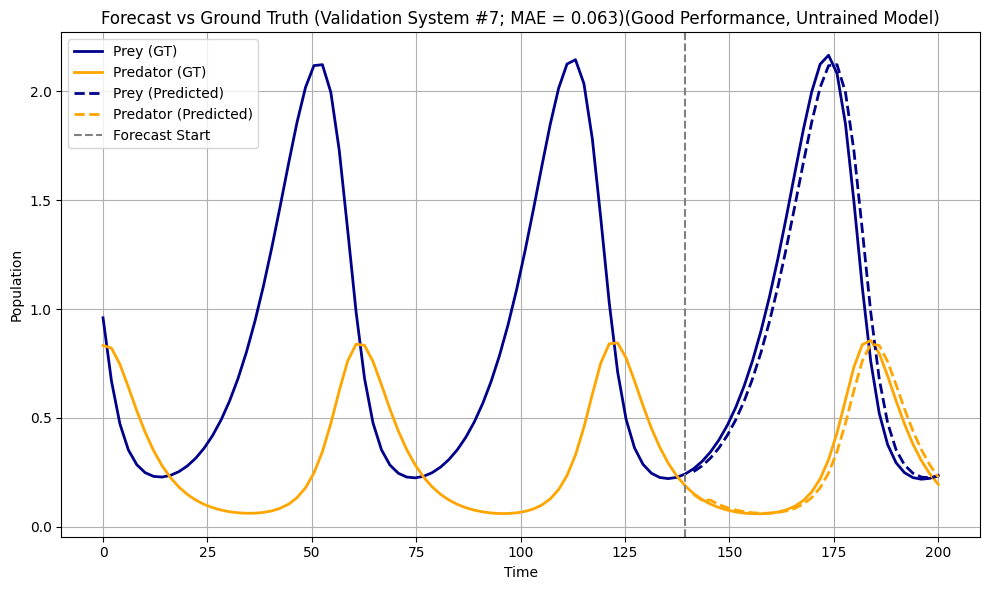

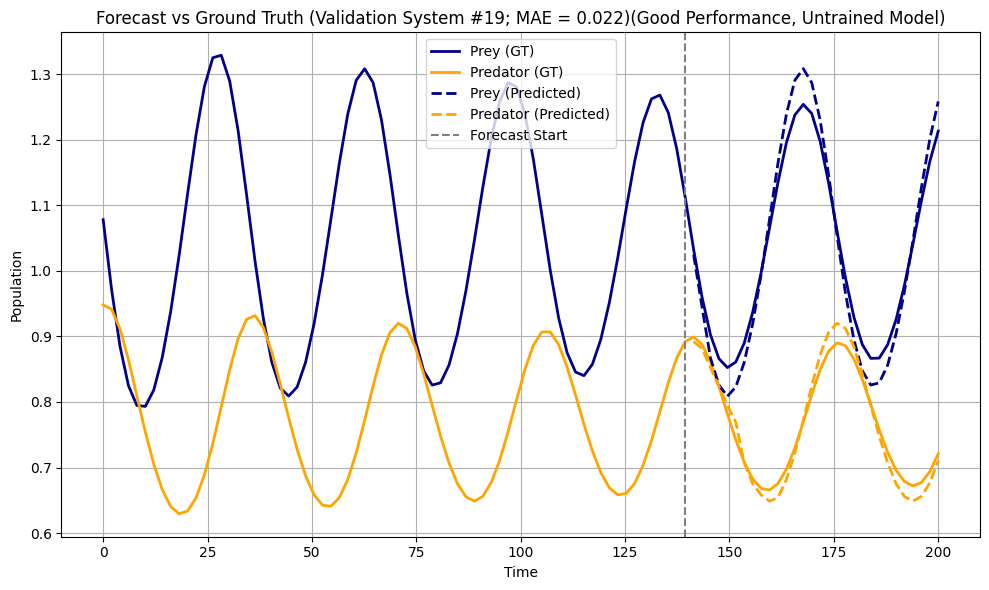

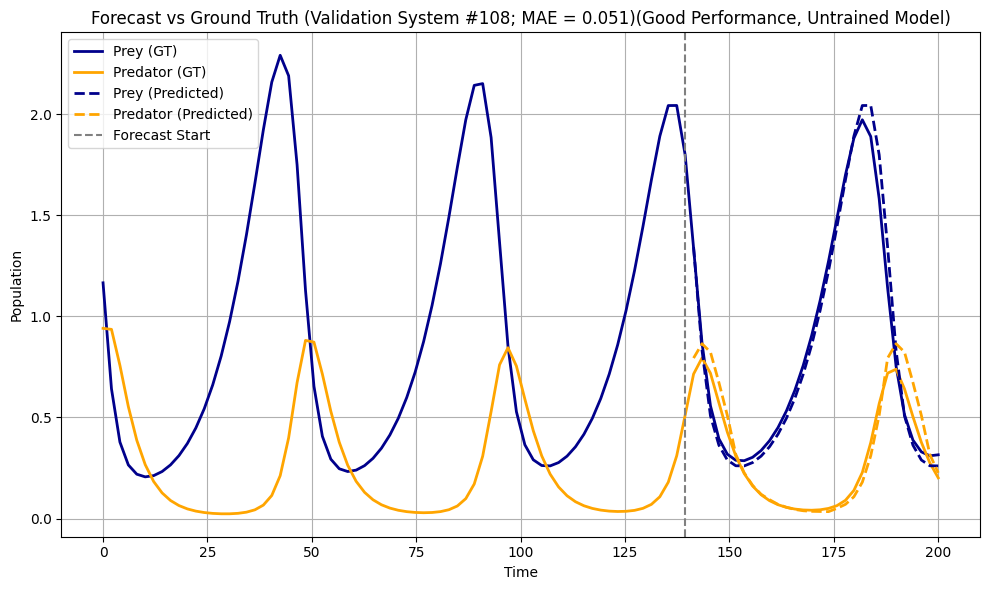

In [42]:
# Good Results Demonstration

chosen_indices = [7, 19, 108]

for i in chosen_indices:
    pred = all_predictions_2b[i]
    gt = all_gt_2b[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue

    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]


    try:
        idx_in_mae_list = system_ids_2b.index(i)
        mae = mae_list_2b[idx_in_mae_list]
    except ValueError:
        mae = None

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    plt.xlabel("Time")
    plt.ylabel("Population")
    if mae is not None:
        plt.title(f"Forecast vs Ground Truth (Validation System #{i}; MAE = {mae:.3f})(Good Performance, Untrained Model)")
    else:
        plt.title(f"Forecast vs Ground Truth (Validation System #{i}; MAE = N/A)(Good Performance, Untrained Model)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


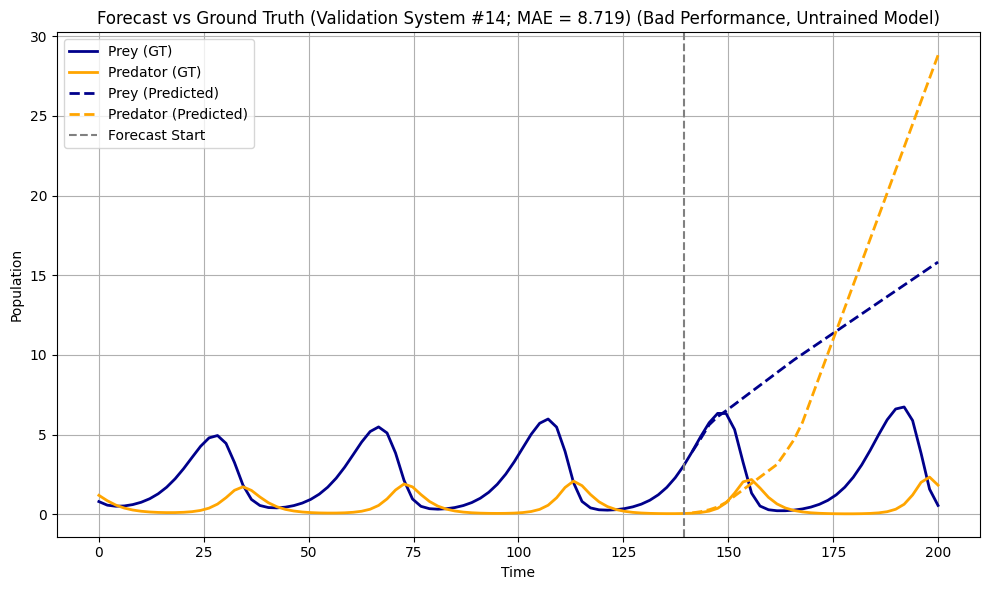

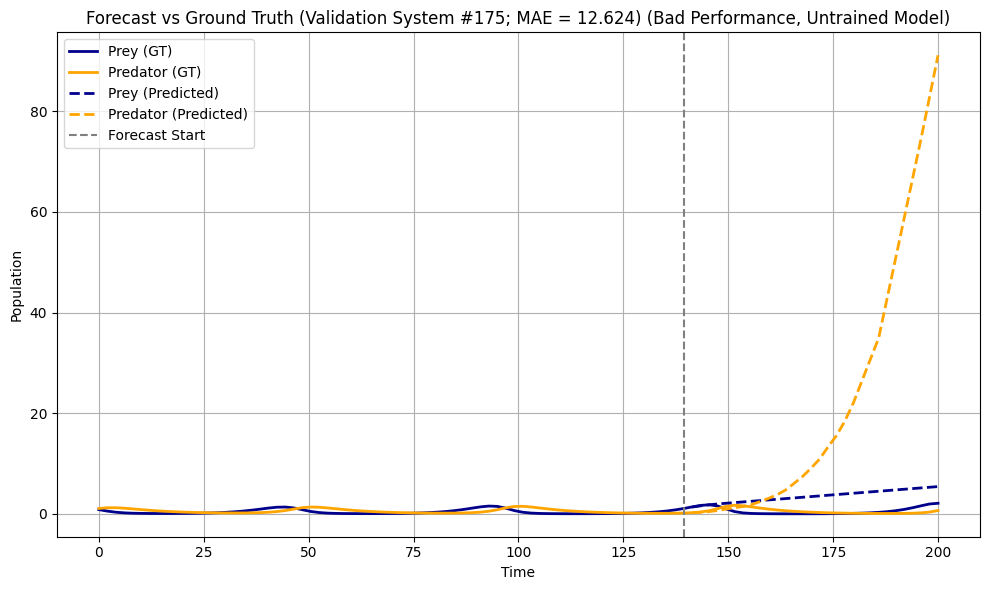

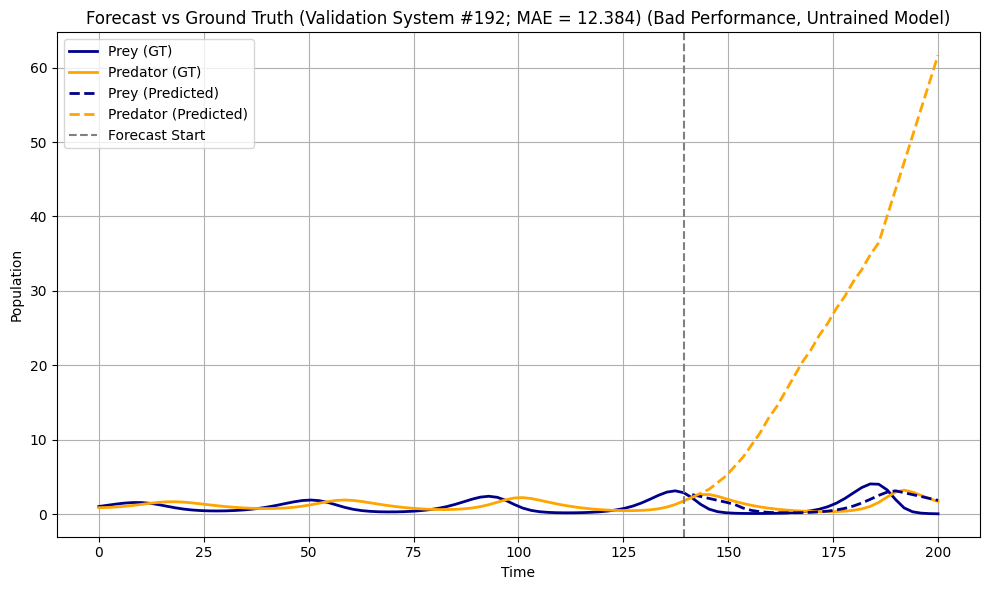

In [45]:
chosen_indices = [14, 175, 192]

for i in chosen_indices:
    pred = all_predictions_2b[i]
    gt = all_gt_2b[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue


    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_2b.index(i)
    mae = mae_list_2b[idx_in_mae_list]

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(f"Forecast vs Ground Truth (Validation System #{i}; MAE = {mae:.3f}) (Bad Performance, Untrained Model)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# 3(a) Try to overfit a small dataset and go through the whole pipeline

In [37]:
# -- Prepare small dataset --

train_init = train_set[0:4]*5
val_init = val_prompt[0:1]


# Tokenise
from lora_implemented import tokenise_data, prepare_data_loader, prepare_model
train_ids_init, val_ids_init = tokenise_data(train_init, val_init, tokenizer)

# Loader
train_loader_init = prepare_data_loader(train_ids_init, batch_size=4)

# Train
from lora_implemented import train

model, tokenizer, optimizer = prepare_model(lora_rank=4, learning_rate=3e-4)
train_losses_init, val_losses_init, _ = train(model, optimizer, train_loader_init, val_ids_init, train_steps=1000, val_every=5)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 975:  96%|█████████▌| 24/25 [00:09<00:00,  2.65it/s, loss=0.0607]


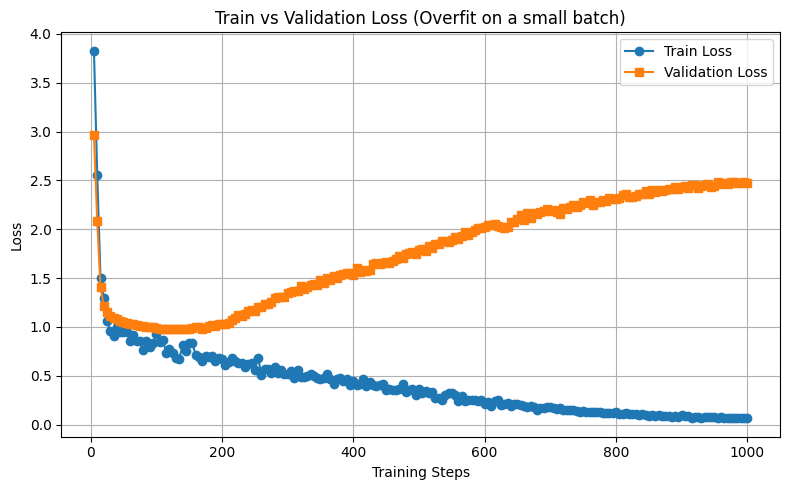

In [38]:
# Visualisation

import matplotlib.pyplot as plt

val_every = 5
steps = list(range(val_every, val_every * len(val_losses_init) + 1, val_every))

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses_init, label="Train Loss", marker='o')
plt.plot(steps, val_losses_init, label="Validation Loss", marker='s')
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss (Overfit on a small batch)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Train the 0.5B parameter model with a single LoRA configuration based on the default hyperparameters, for up to 10,000 optimizer steps, on the training set.

In [4]:
# 3(a) Train on the whole training set based on the default hyperparameters. 

from lora_implemented import train
from lora_implemented import tokenise_data, prepare_data_loader, prepare_model

# Prepare full dataset
train_full = train_set
val_full = val_prompt

model, tokenizer, optimizer = prepare_model(lora_rank=4, learning_rate=1e-5)

# Tokenise
train_ids_full, val_ids_full = tokenise_data(train_full, val_full, tokenizer)


# Loader
train_loader_full = prepare_data_loader(train_ids_full, batch_size=4)

# Train
train_losses_3a, val_losses_3a, _ = train(model, optimizer, train_loader_full, val_ids_full, train_steps=3000, val_every=100)


# Save training data
filename_prefix = "results/3a/experiment"


np.save(f"{filename_prefix}_train_losses.npy", np.array(train_losses_3a))
np.save(f"{filename_prefix}_val_losses.npy", np.array(val_losses_3a))

# LoRA weights
lora_weights = {
    name: param.detach().cpu().clone()
    for name, param in model.named_parameters()
    if param.requires_grad
}
torch.save(lora_weights, f"{filename_prefix}_lora_weights.pth")


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 2016:  98%|█████████▊| 983/1008 [08:20<00:12,  1.96it/s, loss=0.957]  


In [3]:
# Load Model Back

import torch
from lora_implemented import prepare_model

model, tokenizer, _ = prepare_model(lora_rank=4, learning_rate=1e-5)


filename_prefix = "results/3a/experiment"
lora_weights = torch.load(f"{filename_prefix}_lora_weights.pth")

_ = model.load_state_dict(lora_weights, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/tmp/ipykernel_1068216/3908925539.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lora_weights = torch.load(f"{filename_prefix}_lora_weights.pth")


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=896, bias=True)
          )
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): LoRALinear(
            (original_linear): Linear(in_features=896, out_features=128, bias=True)
          )
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm(

In [6]:
# Load Loss Back
train_losses_3a = np.load(f"{filename_prefix}_train_losses.npy")
val_losses_3a = np.load(f"{filename_prefix}_val_losses.npy")

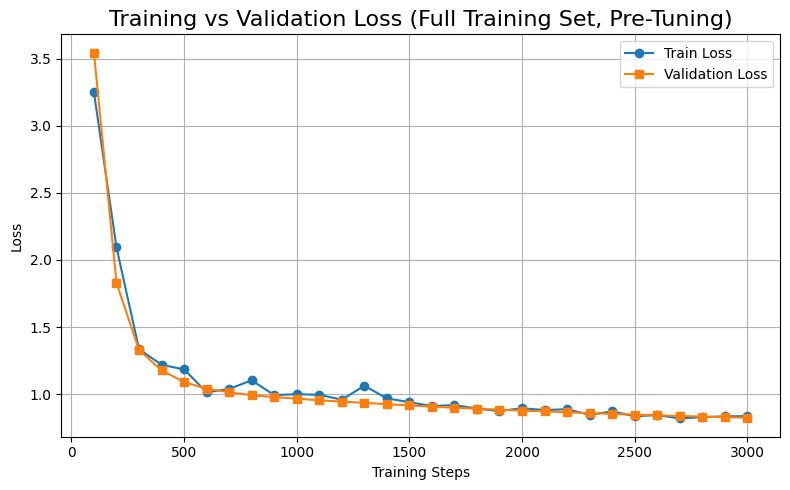

In [7]:
# 3(a): Visualisation
import matplotlib.pyplot as plt

val_every = 100 
steps = list(range(val_every, val_every * len(val_losses_3a) + 1, val_every))

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses_3a, label="Train Loss", marker='o')
plt.plot(steps, val_losses_3a, label="Validation Loss", marker='s')
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Full Training Set, Pre-Tuning)", fontsize = 16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3(a) Evaluate the trained model with default parameters on the validation set

In [8]:
# ====== Predict on entire validation set ======

all_predictions_3a = []  # list of np.ndarray, each of shape (≤30, 2)
all_gt_3a = []           # list of np.ndarray, each of shape (100, 2)

for i, system_id in enumerate(val_idx):
    prompt_string = val_set[1][i]  # 70-point LLMTIME string
    traj_gt = trajectories[system_id]

    try:
        # Predict
        pred_tokens = generate_predictions(
            prompt_string,
            tokenizer=tokenizer,
            model=model,
            device=device,
            max_new_tokens=420,
            num_samples=1,
            do_sample=False
        )[0]

        # Decode and rescale
        decoded_pred = decode_prediction_to_array(pred_tokens)
        rescaled_pred = rescale(decoded_pred, alpha=0.36)

        all_predictions_3a.append(rescaled_pred)
        all_gt_3a.append(traj_gt)

    except Exception as e:
        print(f"[{i}] System {system_id} failed: {e}")
        all_predictions_3a.append(None)
        all_gt_3a.append(traj_gt)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [26]:
import torch.nn.functional as F

mae_list_3a = []
system_ids_3a = []
rmse_list_3a = []

for i, (pred, gt) in enumerate(zip(all_predictions_3a, all_gt_3a)):
    if pred is None:
        continue

    gt_shifted = gt[70:]
    pred_tensor = torch.tensor(pred)

    n = min(30, pred_tensor.shape[0], gt_shifted.shape[0])
    pred_tensor = pred_tensor[:n]
    gt_tensor = torch.tensor(gt_shifted[:n])

    mae = F.l1_loss(pred_tensor, gt_tensor)
    mae_list_3a.append(mae.item())
    system_ids_3a.append(i)
    

    mse = F.mse_loss(pred_tensor, gt_tensor)
    rmse_list_3a.append(torch.sqrt(mse).item())

    
mean_mae_3a = sum(mae_list_3a) / len(mae_list_3a)
mean_rmse_3a = np.mean(rmse_list_3a)

std_mae_3a = np.std(mae_list_3a)
std_rmse_3a = np.std(rmse_list_3a)

print(f"MAE  - Mean: {mean_mae_3a:.4f} | Std: {std_mae_3a:.4f}")
print(f"RMSE - Mean: {mean_rmse_3a:.4f} | Std: {std_rmse_3a:.4f}")

MAE  - Mean: 0.7789 | Std: 2.5804
RMSE - Mean: 1.3623 | Std: 5.7064


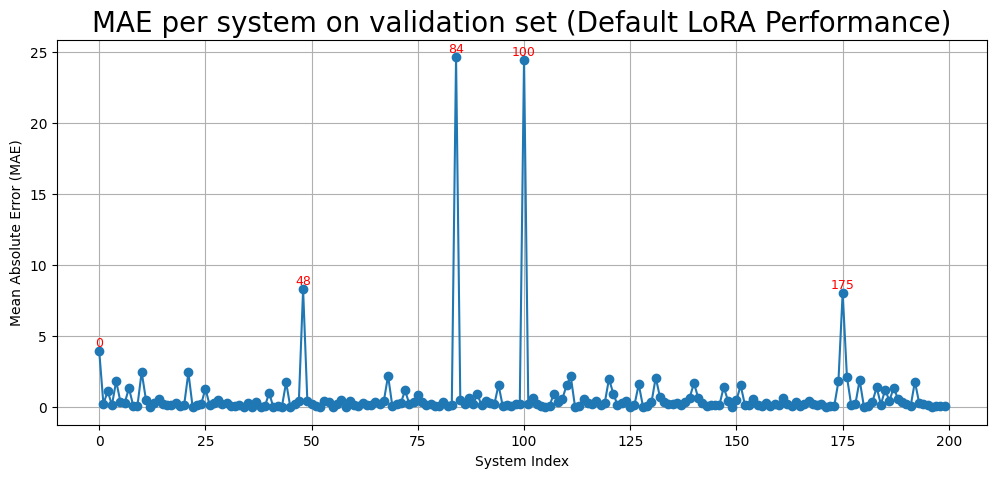

In [20]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# MAE Plot for trained prediction

plt.figure(figsize=(12, 5))
plt.plot(system_ids_3a, mae_list_3a, marker='o')
plt.title("MAE per system on validation set (Default LoRA Performance)", fontsize = 20)
plt.xlabel("System Index")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(True)
#plt.ylim(0, 14)

for sid, mae in zip(system_ids_3a, mae_list_3a):
    if mae > 3:
        plt.text(sid, mae + 0.1, f"{sid}", ha='center', va='bottom', fontsize=9, color='red')


plt.show()


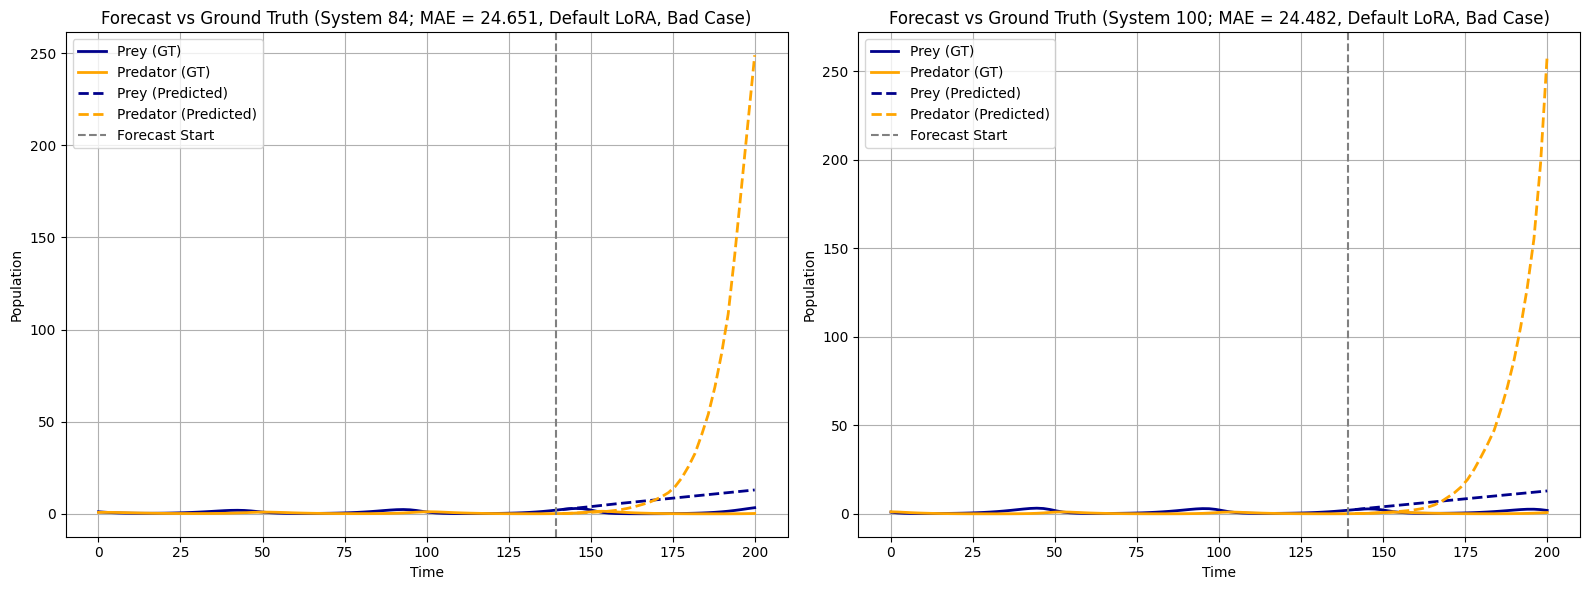

In [32]:
import matplotlib.pyplot as plt

chosen_indices = [84, 100]

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for ax, i in zip(axs, chosen_indices):
    pred = all_predictions_3a[i]
    gt = all_gt_3a[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue

    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_3a.index(i)
    mae = mae_list_3a[idx_in_mae_list]

    # Ground truth
    ax.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    ax.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    ax.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    ax.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    ax.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    ax.set_xlabel("Time")
    ax.set_ylabel("Population")
    ax.set_title(f"Forecast vs Ground Truth (System {i}; MAE = {mae:.3f}, Default LoRA, Bad Case)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


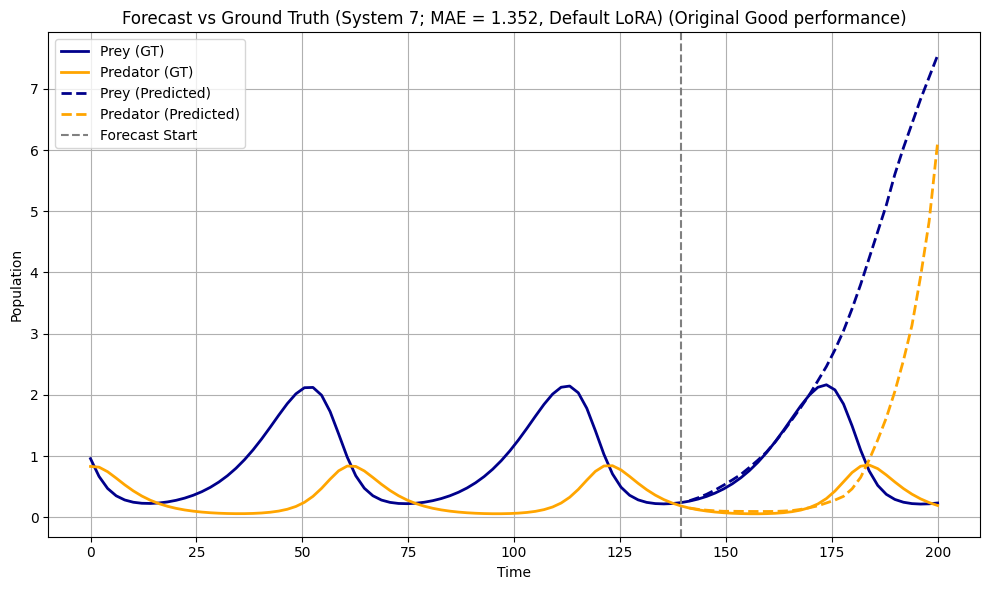

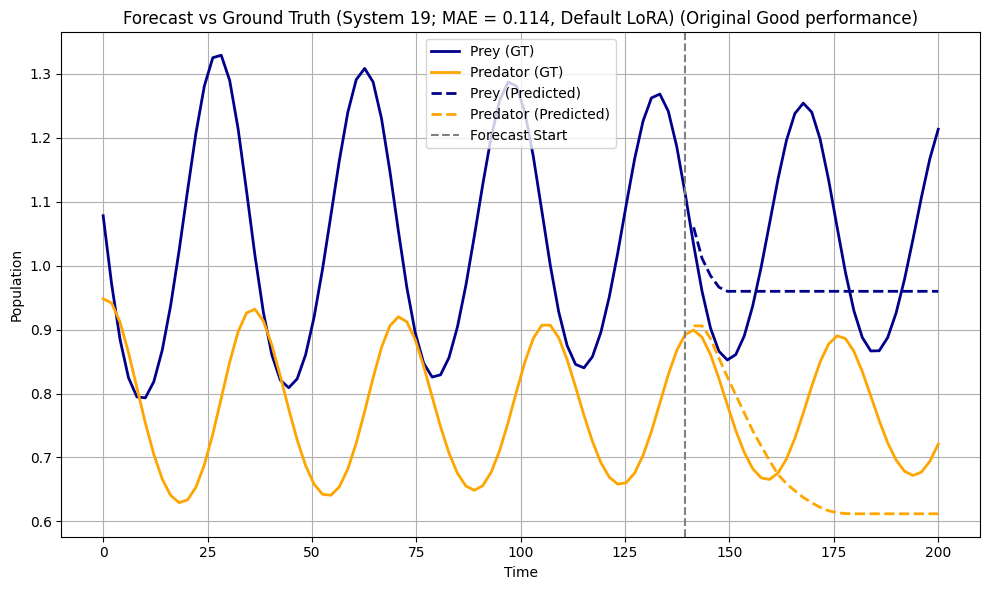

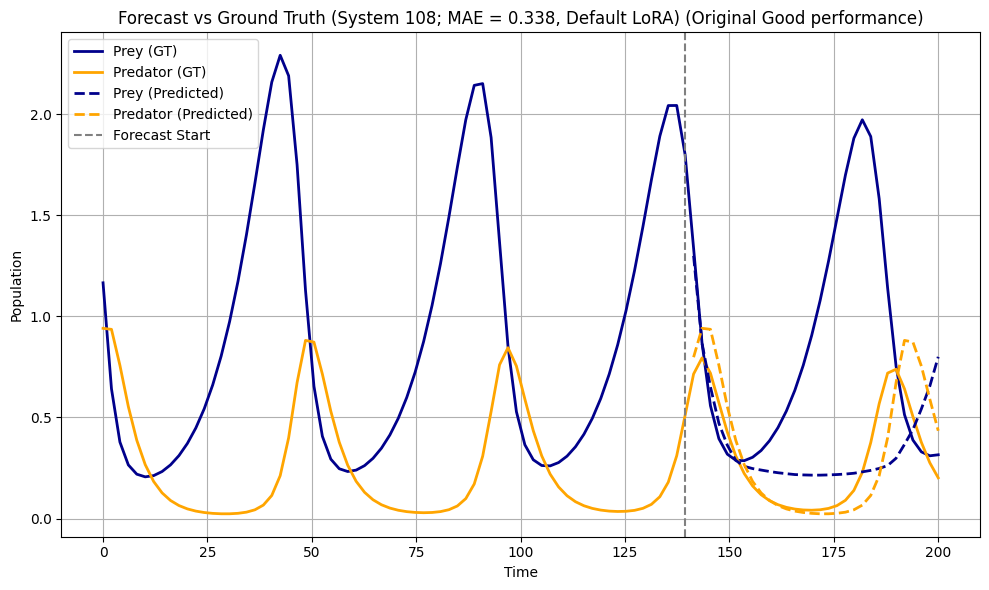

In [21]:
chosen_indices = [7, 19, 108]

for i in chosen_indices:
    pred = all_predictions_3a[i]
    gt = all_gt_3a[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue


    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_3a.index(i)
    mae = mae_list_3a[idx_in_mae_list]

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(f"Forecast vs Ground Truth (System {i}; MAE = {mae:.3f}, Default LoRA) (Original Good performance)" )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


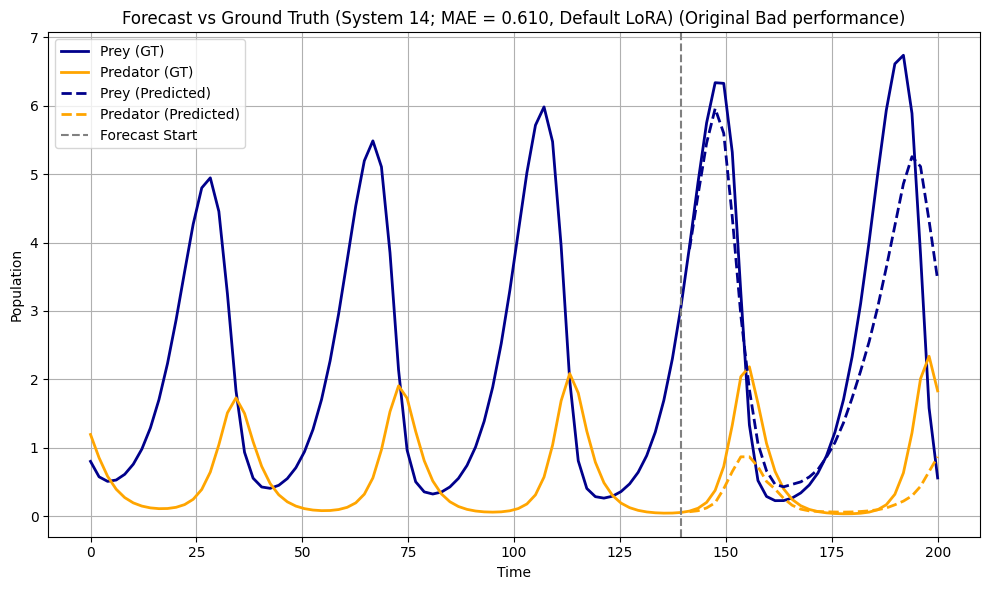

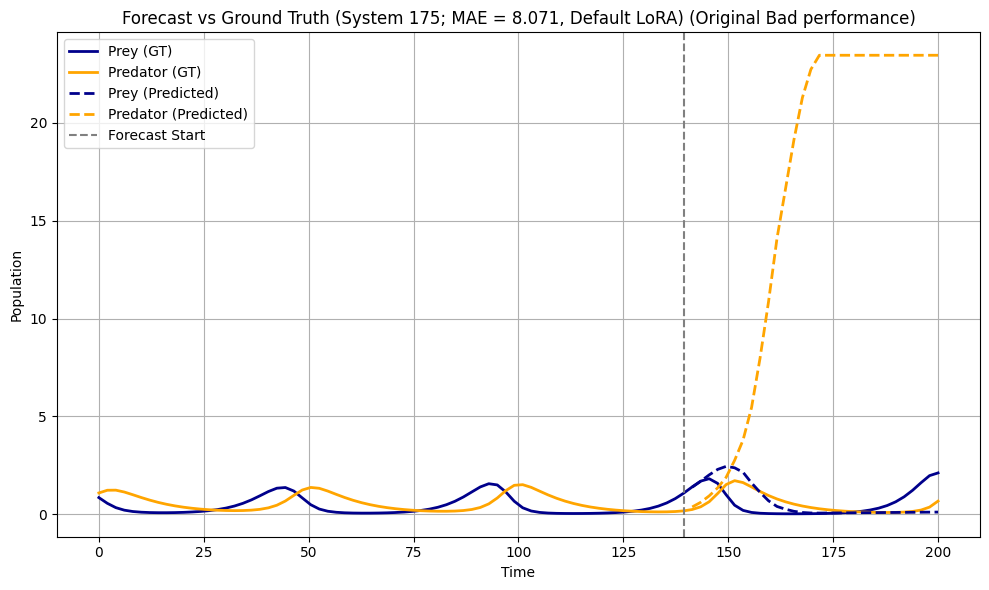

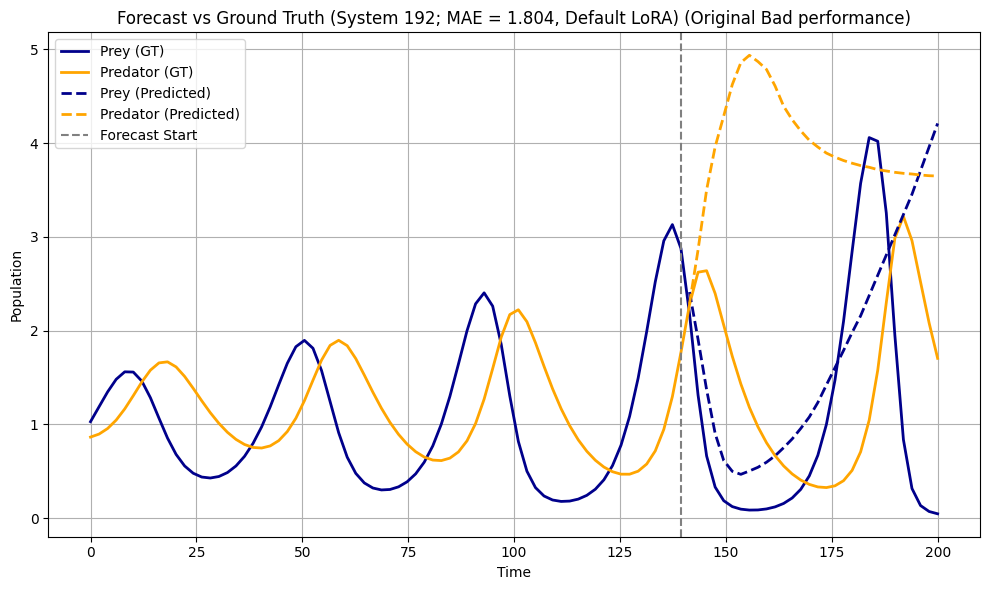

In [22]:
chosen_indices = [14, 175, 192]

for i in chosen_indices:
    pred = all_predictions_3a[i]
    gt = all_gt_3a[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue


    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_3a.index(i)
    mae = mae_list_3a[idx_in_mae_list]

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(f"Forecast vs Ground Truth (System {i}; MAE = {mae:.3f}, Default LoRA) (Original Bad performance)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


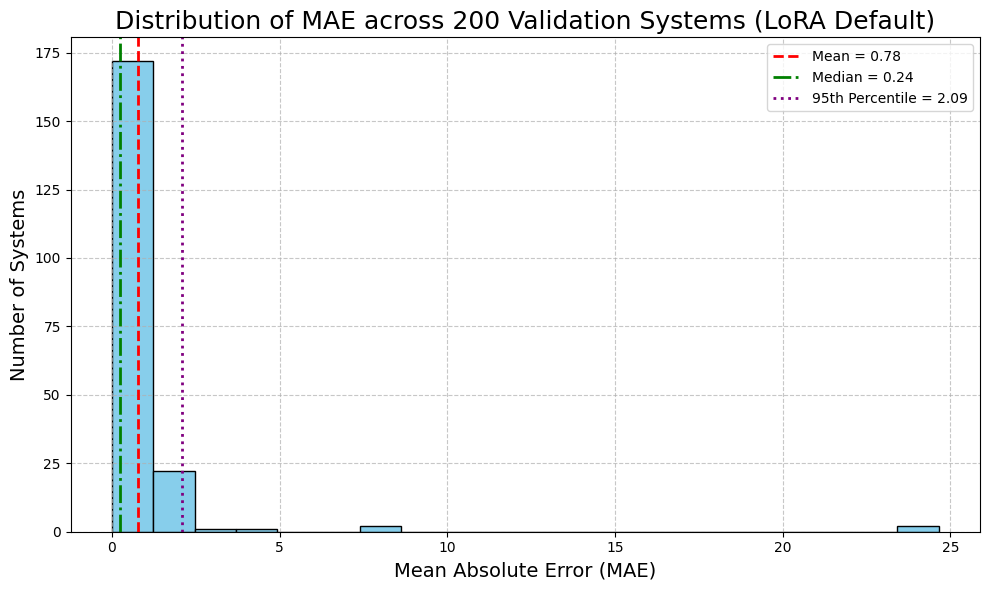

In [25]:
# Histogram of MAE values
import numpy as np
import matplotlib.pyplot as plt

mean_mae = np.mean(mae_list_3a)
median_mae = np.median(mae_list_3a)
percentile95_mae = np.percentile(mae_list_3a, 95)

plt.figure(figsize=(10, 6))
plt.hist(mae_list_3a, bins=20, edgecolor='black', color='skyblue')
plt.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_mae:.2f}")
plt.axvline(median_mae, color='green', linestyle='-.', linewidth=2, label=f"Median = {median_mae:.2f}")
plt.axvline(percentile95_mae, color='purple', linestyle=':', linewidth=2, label=f"95th Percentile = {percentile95_mae:.2f}")

plt.title("Distribution of MAE across 200 Validation Systems (LoRA Default)", fontsize=18)
plt.xlabel("Mean Absolute Error (MAE)", fontsize=14)
plt.ylabel("Number of Systems", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

